In [ ]:
# Enable auto-reloading of modules
%load_ext autoreload
%autoreload 2


In [ ]:
import model_library as ml
import learning_rates as lr

import numpy as np

from keras.models import Model

from keras import backend as K

from matplotlib import pyplot as plt

from experiments import synthetic_data_alignment

from importlib import reload

2025-01-23 13:47:38.377288: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-23 13:47:38.398248: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-23 13:47:38.398266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-23 13:47:38.398830: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-23 13:47:38.402546: I tensorflow/core/platform/cpu_feature_guar

In [3]:
X,Y = synthetic_data_alignment(num_samples=10**5, num_features=256, seq_length=512, p_other=0.3)

In [4]:
X.shape

(100000, 512)

In [5]:
Y.shape

(100000, 256)

In [6]:
np.sum(X[0][X[0] != 2][0:256] ^ Y[0])

0

In [7]:
vgg_model = ml.VGG_1D(512, 32, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)

2025-01-22 18:14:36.367362: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-22 18:14:36.398835: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-22 18:14:36.398944: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [25]:
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [3]:
lr_cyclic = lr.lr_cyclic_sawtooth(20, lr_max=0.001, lr_min = 1e-5, shift=10)

In [28]:
vgg_model.fit(X,Y[:,0:32], epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic])

In [29]:
Zt_vgg = vgg_model.predict(Xt,batch_size=32)

3125/3125 [==============================] - 5s 2ms/step


In [30]:
Zt_vgg_bin = Zt_vgg > 0.5

In [31]:
acc_vgg = np.mean(Zt_vgg_bin == Yt[:,0:32], axis=0)

In [32]:
acc_vgg

array([0.99759, 0.99911, 0.99861, 0.99796, 0.99653, 0.99476, 0.99277,
       0.99063, 0.98672, 0.98346, 0.98   , 0.9733 , 0.96496, 0.96181,
       0.95488, 0.94568, 0.93819, 0.92773, 0.91221, 0.89415, 0.87868,
       0.85811, 0.84069, 0.8265 , 0.81332, 0.80511, 0.79425, 0.78311,
       0.77705, 0.76333, 0.73692, 0.71813])

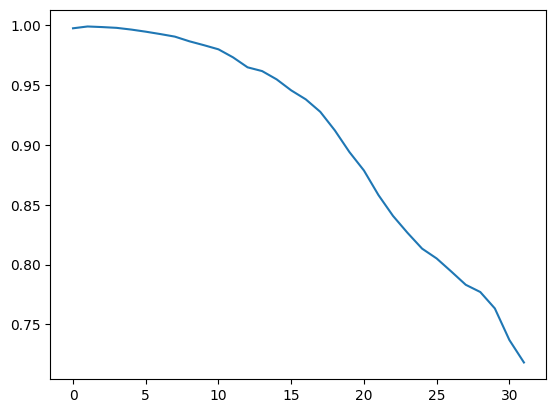

In [33]:
plt.plot(acc_vgg)

In [34]:
nc = ml.net_ches_2018(256, 8, 64, depth=20, output_activation='sigmoid')
nc.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [35]:
nc.fit(X,Y,epochs=101, batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 46s 14ms/step - loss: 0.9773 - binary_accuracy: 0.5008 - val_loss: 0.7728 - val_binary_accuracy: 0.5012 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 38s 13ms/step - loss: 0.7566 - binary_accuracy: 0.5093 - val_loss: 0.7458 - val_binary_accuracy: 0.5159 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 39s 14ms/step - loss: 0.7376 - binary_accuracy: 0.5281 - val_loss: 0.7297 - val_binary_accuracy: 0.5323 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 39s 14ms/step - loss: 0.7203 - binary_accuracy: 0.5419 - val_loss: 0.7124 - val_binary_accuracy: 0.5443 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 40s 14ms/step - loss: 0.7043 - binary_accuracy: 0.5523 - val_loss: 0.6975 - val_binary_accuracy: 0.5571 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 38s 14ms/step - loss: 0.6907 - binary_accuracy: 0.568

In [36]:
Zt_nc = nc.predict(Xt,batch_size=32)

3125/3125 [==============================] - 14s 4ms/step


In [37]:
Zt_nc_bin = Zt_nc > 0.5

In [38]:
acc_nc = np.mean(Zt_nc_bin == Yt, axis=0)

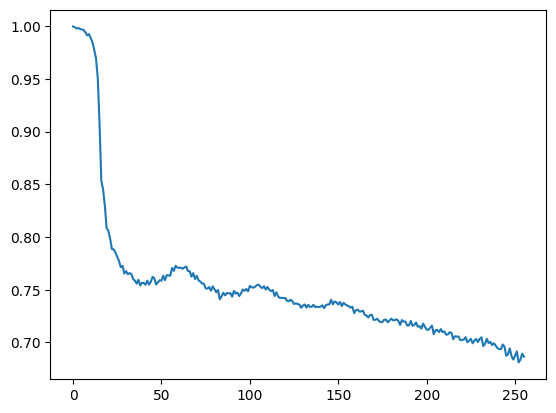

In [39]:
plt.plot(acc_nc)

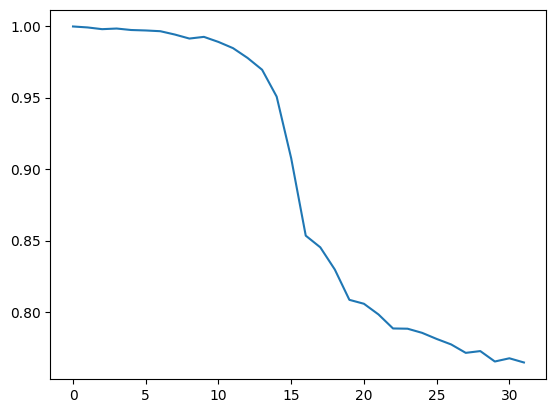

In [40]:
plt.plot(acc_nc[0:32])

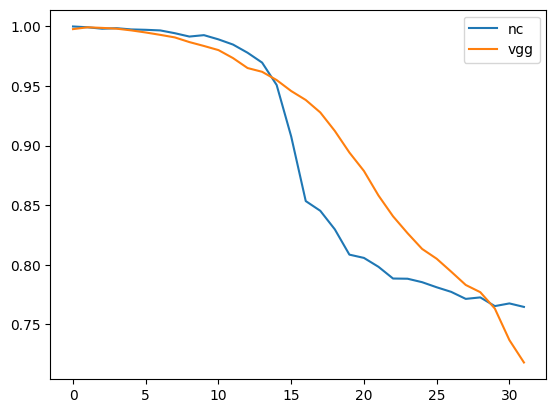

In [41]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg)
plt.legend(["nc","vgg"])

In [53]:
vgg_model = ml.VGG_1D(512, 256, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)

In [54]:
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [55]:
vgg_model.fit(X,Y, epochs=101, batch_size=32, validation_split=0.1, callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 22s 7ms/step - loss: 0.8141 - binary_accuracy: 0.5032 - val_loss: 0.7963 - val_binary_accuracy: 0.5070 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 24s 8ms/step - loss: 0.7081 - binary_accuracy: 0.5463 - val_loss: 0.6812 - val_binary_accuracy: 0.5705 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 25s 9ms/step - loss: 0.6768 - binary_accuracy: 0.5775 - val_loss: 0.6714 - val_binary_accuracy: 0.5865 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6632 - binary_accuracy: 0.5988 - val_loss: 0.6506 - val_binary_accuracy: 0.6157 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6460 - binary_accuracy: 0.6192 - val_loss: 0.6395 - val_binary_accuracy: 0.6261 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6358 - binary_accuracy: 0.6297 - va

In [56]:
Zt_vgg = vgg_model.predict(Xt,batch_size=32)

3125/3125 [==============================] - 4s 1ms/step


In [57]:
Zt_vgg_bin = Zt_vgg > 0.5

In [58]:
acc_vgg = np.mean(Zt_vgg_bin == Yt, axis=0)

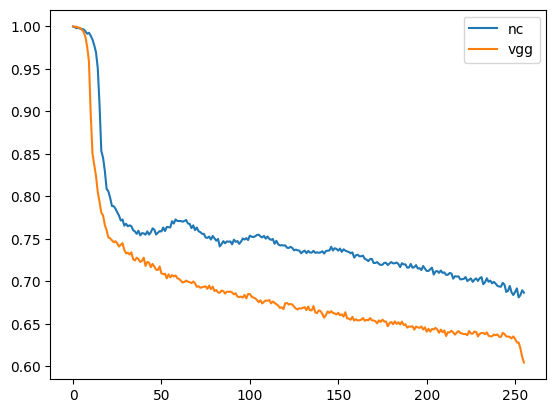

In [59]:
plt.plot(acc_nc)
plt.plot(acc_vgg)
plt.legend(['nc','vgg'])

In [60]:
nc.summary()

Model: "model_5"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_6 (InputLayer)        [(None, 512)]                0         []                            
                                                                                                  
 reshape_5 (Reshape)         (None, 8, 64)                0         ['input_6[0][0]']             
                                                                                                  
 batch_normalization_35 (Ba  (None, 8, 64)                256       ['reshape_5[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 conv1d_20 (Conv1D)          (None, 8, 256)               16640     ['batch_normalization_35

In [62]:
vgg_model.summary()

Model: "model_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_12 (InputLayer)       [(None, 512)]             0         
                                                                 
 reshape_6 (Reshape)         (None, 512, 1)            0         
                                                                 
 conv1d_122 (Conv1D)         (None, 512, 32)           128       
                                                                 
 batch_normalization_132 (B  (None, 512, 32)           128       
 atchNormalization)                                              
                                                                 
 max_pooling1d_48 (MaxPooli  (None, 256, 32)           0         
 ng1D)                                                           
                                                                 
 conv1d_123 (Conv1D)         (None, 256, 64)           6208

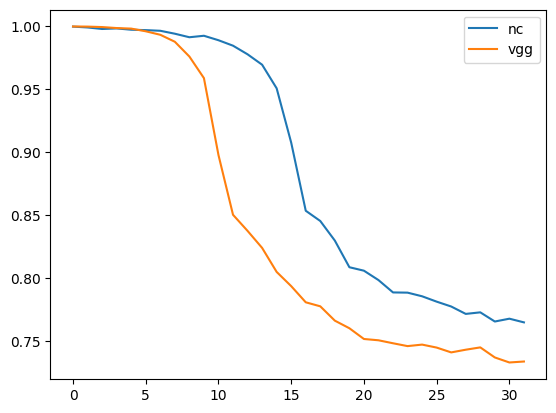

In [63]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg[0:32])
plt.legend(['nc','vgg'])

In [64]:
nc.fit(X,Y,epochs=21, batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.5211 - binary_accuracy: 0.7333 - val_loss: 0.4958 - val_binary_accuracy: 0.7532 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 34s 12ms/step - loss: 0.5239 - binary_accuracy: 0.7314 - val_loss: 0.5040 - val_binary_accuracy: 0.7458 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 37s 13ms/step - loss: 0.5283 - binary_accuracy: 0.7282 - val_loss: 0.4999 - val_binary_accuracy: 0.7504 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 35s 12ms/step - loss: 0.5336 - binary_accuracy: 0.7245 - val_loss: 0.5156 - val_binary_accuracy: 0.7377 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 33s 12ms/step - loss: 0.5371 - binary_accuracy: 0.7223 - val_loss: 0.5219 - val_binary_accuracy: 0.7336 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 35s 12ms/step - loss: 0.5419 - binary_accuracy: 0.7194 - va

In [65]:
Zt_nc2 = nc.predict(Xt,batch_size=32)

3125/3125 [==============================] - 11s 3ms/step


In [66]:
Zt_nc2_bin = Zt_nc2 > 0.5

In [67]:
acc_nc2 = np.mean(Zt_nc2_bin == Yt, axis=0)

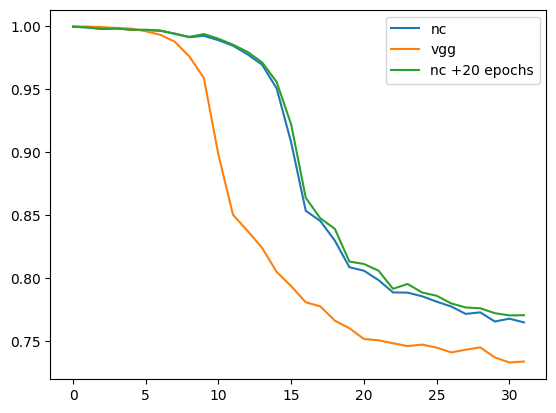

In [68]:
plt.plot(acc_nc[0:32])
plt.plot(acc_vgg[0:32])
plt.plot(acc_nc2[0:32])
plt.legend(['nc','vgg','nc +20 epochs'])

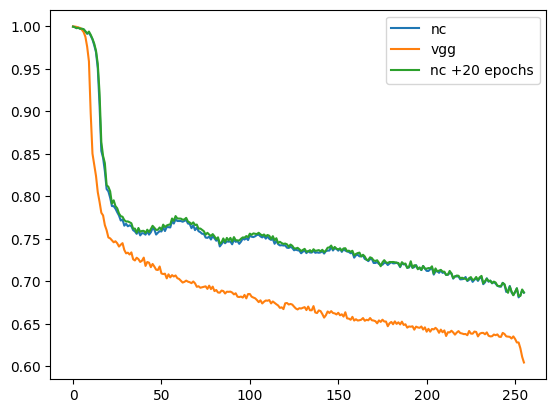

In [69]:
plt.plot(acc_nc)
plt.plot(acc_vgg)
plt.plot(acc_nc2)
plt.legend(['nc','vgg','nc +20 epochs'])

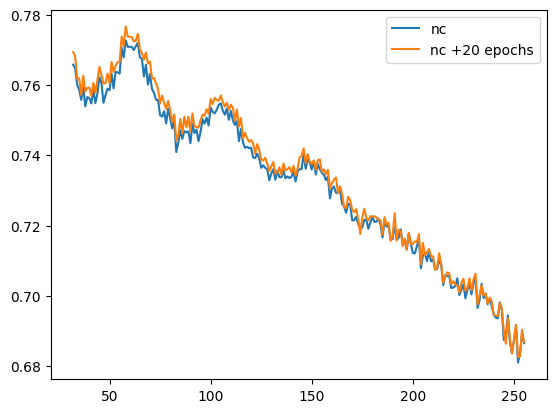

In [72]:
plt.plot(np.arange(32,256),acc_nc[32:])
plt.plot(np.arange(32,256),acc_nc2[32:])
plt.legend(['nc','nc +20 epochs'])

In [102]:
import Transformer
reload(Transformer)
model = Transformer.create_transformer_model((512,), 1, 128, 5, 64, output_activation='sigmoid',outputs=8, dense_nodes=512)

In [103]:
model.summary()

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_31 (InputLayer)       [(None, 512, 1)]          0         
                                                                 
 conv1d_135 (Conv1D)         (None, 512, 128)          2304      
                                                                 
 token_and_position_embeddi  (None, 512, 128)          82048     
 ng_8 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 transformer_block_62 (Tran  (None, 512, 128)          347072    
 sformerBlock)                                                   
                                                                 
 global_max_pooling1d_8 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                        

In [104]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
model.fit(X,Y[:,0:8],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.7030 - binary_accuracy: 0.5064 - val_loss: 0.6931 - val_binary_accuracy: 0.5109 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.4796 - binary_accuracy: 0.7366 - val_loss: 0.3531 - val_binary_accuracy: 0.8184 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.2266 - binary_accuracy: 0.8892 - val_loss: 0.0821 - val_binary_accuracy: 0.9664 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.0480 - binary_accuracy: 0.9804 - val_loss: 0.0352 - val_binary_accuracy: 0.9850 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 66s 23ms/step - loss: 0.0289 - binary_accuracy: 0.9884 - val_loss: 0.0287 - val_binary_accuracy: 0.9873 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.0267 - binary_accuracy: 0.9896 - va

In [105]:
model.fit(X,Y[:,8:16],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 61s 22ms/step - loss: 0.8896 - binary_accuracy: 0.5059 - val_loss: 1.5784 - val_binary_accuracy: 0.4994 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.5605 - binary_accuracy: 0.6483 - val_loss: 0.4984 - val_binary_accuracy: 0.7244 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.3265 - binary_accuracy: 0.8194 - val_loss: 0.2620 - val_binary_accuracy: 0.8613 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 61s 22ms/step - loss: 0.1785 - binary_accuracy: 0.9109 - val_loss: 0.0817 - val_binary_accuracy: 0.9643 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.0709 - binary_accuracy: 0.9673 - val_loss: 0.0488 - val_binary_accuracy: 0.9787 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 66s 23ms/step - loss: 0.0515 - binary_accuracy: 0.9757 - va

In [106]:
model.fit(X,Y[:,16:24],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 64s 23ms/step - loss: 1.0201 - binary_accuracy: 0.5081 - val_loss: 0.7707 - val_binary_accuracy: 0.5136 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 64s 23ms/step - loss: 0.6250 - binary_accuracy: 0.6126 - val_loss: 0.7668 - val_binary_accuracy: 0.6510 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.4495 - binary_accuracy: 0.7446 - val_loss: 0.5374 - val_binary_accuracy: 0.7693 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.3265 - binary_accuracy: 0.8189 - val_loss: 0.3791 - val_binary_accuracy: 0.8463 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.2171 - binary_accuracy: 0.8846 - val_loss: 0.2143 - val_binary_accuracy: 0.9089 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 68s 24ms/step - loss: 0.1523 - binary_accuracy: 0.9173 - va

In [109]:
vgg_model = ml.VGG_1D(512, 8, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')

In [110]:
vgg_model.fit(X,Y[:,0:8],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.8172 - binary_accuracy: 0.5177 - val_loss: 0.7696 - val_binary_accuracy: 0.5365 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6472 - binary_accuracy: 0.6337 - val_loss: 0.5424 - val_binary_accuracy: 0.7053 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.4171 - binary_accuracy: 0.7854 - val_loss: 0.2968 - val_binary_accuracy: 0.8543 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.2315 - binary_accuracy: 0.8894 - val_loss: 0.1440 - val_binary_accuracy: 0.9346 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.1264 - binary_accuracy: 0.9456 - val_loss: 0.0779 - val_binary_accuracy: 0.9688 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.0779 - binary_accuracy: 0.9694 - val_loss

In [111]:
vgg_model.fit(X,Y[:,8:16],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 5.1936 - binary_accuracy: 0.5117 - val_loss: 3.0023 - val_binary_accuracy: 0.5286 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.9596 - binary_accuracy: 0.5545 - val_loss: 0.6842 - val_binary_accuracy: 0.5864 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6162 - binary_accuracy: 0.6386 - val_loss: 0.6869 - val_binary_accuracy: 0.7107 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.4946 - binary_accuracy: 0.7390 - val_loss: 0.4581 - val_binary_accuracy: 0.7849 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.4024 - binary_accuracy: 0.7971 - val_loss: 0.6761 - val_binary_accuracy: 0.8372 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.3312 - binary_accuracy: 0.8396 - val_loss

In [112]:
vgg_model.fit(X,Y[:,16:24],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 9ms/step - loss: 3.3721 - binary_accuracy: 0.5031 - val_loss: 2.4870 - val_binary_accuracy: 0.5076 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.9870 - binary_accuracy: 0.5320 - val_loss: 0.7508 - val_binary_accuracy: 0.5671 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6618 - binary_accuracy: 0.6014 - val_loss: 0.6282 - val_binary_accuracy: 0.6421 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5866 - binary_accuracy: 0.6734 - val_loss: 0.5675 - val_binary_accuracy: 0.7167 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5153 - binary_accuracy: 0.7289 - val_loss: 0.4882 - val_binary_accuracy: 0.7646 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.4546 - binary_accuracy: 0.7703 - val_loss

In [113]:
model.fit(X,Y[:,24:32],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 67s 24ms/step - loss: 1.0895 - binary_accuracy: 0.5019 - val_loss: 1.8602 - val_binary_accuracy: 0.5039 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.6757 - binary_accuracy: 0.5581 - val_loss: 3.3160 - val_binary_accuracy: 0.5284 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 62s 22ms/step - loss: 0.5807 - binary_accuracy: 0.6659 - val_loss: 1.6872 - val_binary_accuracy: 0.6188 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 63s 22ms/step - loss: 0.4094 - binary_accuracy: 0.7750 - val_loss: 0.9099 - val_binary_accuracy: 0.7583 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.2534 - binary_accuracy: 0.8554 - val_loss: 0.6800 - val_binary_accuracy: 0.8335 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 67s 24ms/step - loss: 0.2068 - binary_accuracy: 0.8841 - va

In [114]:
vgg_model.fit(X,Y[:,24:32],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 22s 8ms/step - loss: 2.2068 - binary_accuracy: 0.5065 - val_loss: 1.5273 - val_binary_accuracy: 0.5151 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8349 - binary_accuracy: 0.5452 - val_loss: 0.7405 - val_binary_accuracy: 0.5852 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6688 - binary_accuracy: 0.6104 - val_loss: 0.6518 - val_binary_accuracy: 0.6489 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6142 - binary_accuracy: 0.6629 - val_loss: 0.6005 - val_binary_accuracy: 0.6928 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.5733 - binary_accuracy: 0.6984 - val_loss: 0.5809 - val_binary_accuracy: 0.7236 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5361 - binary_accuracy: 0.7241 - val_loss

In [116]:
model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.8116 - binary_accuracy: 0.5040 - val_loss: 3.5154 - val_binary_accuracy: 0.5059 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.5790 - binary_accuracy: 0.6288 - val_loss: 4.0867 - val_binary_accuracy: 0.6034 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 62s 22ms/step - loss: 0.4656 - binary_accuracy: 0.7000 - val_loss: 3.3425 - val_binary_accuracy: 0.6427 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.4424 - binary_accuracy: 0.7105 - val_loss: 2.9307 - val_binary_accuracy: 0.6625 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 66s 24ms/step - loss: 0.4287 - binary_accuracy: 0.7160 - val_loss: 2.9809 - val_binary_accuracy: 0.6855 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 65s 23ms/step - loss: 0.6051 - binary_accuracy: 0.5723 - va

In [117]:
vgg_model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 21s 8ms/step - loss: 1.4712 - binary_accuracy: 0.5068 - val_loss: 1.1647 - val_binary_accuracy: 0.5167 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.7555 - binary_accuracy: 0.5589 - val_loss: 0.7337 - val_binary_accuracy: 0.6012 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6533 - binary_accuracy: 0.6261 - val_loss: 0.6393 - val_binary_accuracy: 0.6628 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6001 - binary_accuracy: 0.6735 - val_loss: 0.5628 - val_binary_accuracy: 0.7028 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5580 - binary_accuracy: 0.7075 - val_loss: 0.5305 - val_binary_accuracy: 0.7335 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5302 - binary_accuracy: 0.7272 - val_loss

In [118]:
vgg_model.summary()

Model: "model_19"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_33 (InputLayer)       [(None, 512)]             0         
                                                                 
 reshape_18 (Reshape)        (None, 512, 1)            0         
                                                                 
 conv1d_140 (Conv1D)         (None, 512, 32)           128       
                                                                 
 batch_normalization_146 (B  (None, 512, 32)           128       
 atchNormalization)                                              
                                                                 
 max_pooling1d_56 (MaxPooli  (None, 256, 32)           0         
 ng1D)                                                           
                                                                 
 conv1d_141 (Conv1D)         (None, 256, 64)           620

In [119]:
model.summary()

Model: "model_17"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_31 (InputLayer)       [(None, 512, 1)]          0         
                                                                 
 conv1d_135 (Conv1D)         (None, 512, 128)          2304      
                                                                 
 token_and_position_embeddi  (None, 512, 128)          82048     
 ng_8 (TokenAndPositionEmbe                                      
 dding)                                                          
                                                                 
 transformer_block_62 (Tran  (None, 512, 128)          347072    
 sformerBlock)                                                   
                                                                 
 global_max_pooling1d_8 (Gl  (None, 128)               0         
 obalMaxPooling1D)                                        

In [120]:
vgg_model.fit(X,Y[:,32:40],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.2899 - binary_accuracy: 0.8746 - val_loss: 0.3474 - val_binary_accuracy: 0.8446 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 18s 6ms/step - loss: 0.2959 - binary_accuracy: 0.8714 - val_loss: 0.3523 - val_binary_accuracy: 0.8434 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.2970 - binary_accuracy: 0.8709 - val_loss: 0.3589 - val_binary_accuracy: 0.8416 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.3045 - binary_accuracy: 0.8669 - val_loss: 0.3623 - val_binary_accuracy: 0.8381 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 25s 9ms/step - loss: 0.3045 - binary_accuracy: 0.8670 - val_loss: 0.3837 - val_binary_accuracy: 0.8310 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.3086 - binary_accuracy: 0.8654 - val_loss

In [121]:
vgg_model.fit(X,Y[:,40:48],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 1.8404 - binary_accuracy: 0.5072 - val_loss: 1.4913 - val_binary_accuracy: 0.5143 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8391 - binary_accuracy: 0.5493 - val_loss: 0.7086 - val_binary_accuracy: 0.5911 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.6683 - binary_accuracy: 0.6165 - val_loss: 0.6760 - val_binary_accuracy: 0.6546 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6079 - binary_accuracy: 0.6706 - val_loss: 0.5754 - val_binary_accuracy: 0.7007 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 28s 10ms/step - loss: 0.5639 - binary_accuracy: 0.7053 - val_loss: 0.5281 - val_binary_accuracy: 0.7310 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 27s 9ms/step - loss: 0.5369 - binary_accuracy: 0.7239 - val_los

In [123]:
vgg_model2 = ml.VGG_1D(512, 8, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model2.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
vgg_model2.fit(X,Y[:,40:48],epochs=101,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.8241 - binary_accuracy: 0.5119 - val_loss: 0.7871 - val_binary_accuracy: 0.5212 - lr: 1.0000e-05
Epoch 2/101
2813/2813 [==============================] - 21s 8ms/step - loss: 0.7182 - binary_accuracy: 0.5594 - val_loss: 0.7052 - val_binary_accuracy: 0.5683 - lr: 1.0900e-04
Epoch 3/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6701 - binary_accuracy: 0.6030 - val_loss: 0.6712 - val_binary_accuracy: 0.6076 - lr: 2.0800e-04
Epoch 4/101
2813/2813 [==============================] - 23s 8ms/step - loss: 0.6466 - binary_accuracy: 0.6285 - val_loss: 0.6437 - val_binary_accuracy: 0.6316 - lr: 3.0700e-04
Epoch 5/101
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6302 - binary_accuracy: 0.6450 - val_loss: 0.6200 - val_binary_accuracy: 0.6530 - lr: 4.0600e-04
Epoch 6/101
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6094 - binary_accuracy: 0.6632 - va

In [124]:
vgg_model.fit(X,Y[:,40:48],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3082 - binary_accuracy: 0.8660 - val_loss: 0.4199 - val_binary_accuracy: 0.8104 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.3126 - binary_accuracy: 0.8635 - val_loss: 0.4327 - val_binary_accuracy: 0.8077 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3172 - binary_accuracy: 0.8609 - val_loss: 0.4298 - val_binary_accuracy: 0.8067 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 25s 9ms/step - loss: 0.3186 - binary_accuracy: 0.8603 - val_loss: 0.4291 - val_binary_accuracy: 0.8069 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.3219 - binary_accuracy: 0.8582 - val_loss: 0.4519 - val_binary_accuracy: 0.7956 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.3243 - binary_accuracy: 0.8578 - val_loss

In [125]:
vgg_model.fit(X,Y[:,48:56],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 23s 8ms/step - loss: 1.7086 - binary_accuracy: 0.5091 - val_loss: 1.4349 - val_binary_accuracy: 0.5148 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.8409 - binary_accuracy: 0.5466 - val_loss: 0.7251 - val_binary_accuracy: 0.5848 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.6706 - binary_accuracy: 0.6135 - val_loss: 0.6592 - val_binary_accuracy: 0.6485 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6191 - binary_accuracy: 0.6596 - val_loss: 0.5809 - val_binary_accuracy: 0.6899 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.5786 - binary_accuracy: 0.6925 - val_loss: 0.5505 - val_binary_accuracy: 0.7167 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.5525 - binary_accuracy: 0.7107 - val_loss

In [126]:
vgg_model.fit(X,Y[:,56:64],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 24s 8ms/step - loss: 1.1682 - binary_accuracy: 0.5092 - val_loss: 1.0052 - val_binary_accuracy: 0.5168 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 19s 7ms/step - loss: 0.7452 - binary_accuracy: 0.5605 - val_loss: 0.6813 - val_binary_accuracy: 0.6024 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.6492 - binary_accuracy: 0.6280 - val_loss: 0.6183 - val_binary_accuracy: 0.6633 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6026 - binary_accuracy: 0.6702 - val_loss: 0.5764 - val_binary_accuracy: 0.6986 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.5712 - binary_accuracy: 0.6949 - val_loss: 0.5423 - val_binary_accuracy: 0.7169 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.5506 - binary_accuracy: 0.7097 - val_loss

In [127]:
vgg_model.fit(X,Y[:,64:72],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 25s 9ms/step - loss: 1.0685 - binary_accuracy: 0.5120 - val_loss: 0.9522 - val_binary_accuracy: 0.5228 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 24s 9ms/step - loss: 0.7258 - binary_accuracy: 0.5655 - val_loss: 0.8493 - val_binary_accuracy: 0.6099 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 21s 7ms/step - loss: 0.6475 - binary_accuracy: 0.6281 - val_loss: 0.6601 - val_binary_accuracy: 0.6660 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 24s 8ms/step - loss: 0.6034 - binary_accuracy: 0.6676 - val_loss: 0.5845 - val_binary_accuracy: 0.6995 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5728 - binary_accuracy: 0.6923 - val_loss: 0.5330 - val_binary_accuracy: 0.7204 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 20s 7ms/step - loss: 0.5545 - binary_accuracy: 0.7065 - val_loss

In [128]:
vgg_model.fit(X,Y[:,72:80],epochs=21,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])

Epoch 1/21
2813/2813 [==============================] - 26s 9ms/step - loss: 1.0477 - binary_accuracy: 0.5116 - val_loss: 0.9616 - val_binary_accuracy: 0.5197 - lr: 1.0000e-05
Epoch 2/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.7285 - binary_accuracy: 0.5610 - val_loss: 0.7271 - val_binary_accuracy: 0.6022 - lr: 1.0900e-04
Epoch 3/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6448 - binary_accuracy: 0.6279 - val_loss: 0.7072 - val_binary_accuracy: 0.6637 - lr: 2.0800e-04
Epoch 4/21
2813/2813 [==============================] - 22s 8ms/step - loss: 0.6004 - binary_accuracy: 0.6683 - val_loss: 0.5726 - val_binary_accuracy: 0.6978 - lr: 3.0700e-04
Epoch 5/21
2813/2813 [==============================] - 26s 9ms/step - loss: 0.5751 - binary_accuracy: 0.6893 - val_loss: 0.5480 - val_binary_accuracy: 0.7100 - lr: 4.0600e-04
Epoch 6/21
2813/2813 [==============================] - 23s 8ms/step - loss: 0.5560 - binary_accuracy: 0.7031 - val_loss

In [4]:
unet = ml.unet_1d(512, output_size=512,output_channels=3, output_activation='softmax')

2025-01-23 13:47:54.584001: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-23 13:47:54.616740: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-01-23 13:47:54.616866: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

In [5]:
from experiments import synthetic_data_alignment_clean
X,Y = synthetic_data_alignment_clean(num_samples=10**4, num_features=32, seq_length=512, noise=0.0)

In [6]:
print(X.shape)
print(Y.shape)
print(X[0][0:32])
print(Y[0])

(10000, 512)
(10000, 32)
[2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2]
[0 0 0 0 1 0 1 0 0 1 0 0 1 1 0 1 0 0 0 1 0 0 1 1 1 1 0 0 1 0 0 0]


In [7]:
from keras.layers import Lambda, Input
# Add CTC loss configuration
def ctc_lambda_func(args):
    y_pred, labels, input_length, label_length = args
    return K.ctc_batch_cost(labels, y_pred, input_length, label_length)

# Create input tensors for CTC
labels = Input(name='labels', shape=(32,), dtype='float32')  # Your target sequence length is 32
input_length = Input(name='input_length', shape=(1,))
label_length = Input(name='label_length', shape=(1,))

# Define loss output
loss_out = Lambda(ctc_lambda_func, output_shape=(1,), name='ctc')([unet.output, labels, input_length, label_length])

# Create training model
model = Model(inputs=[unet.input, labels, input_length, label_length], outputs=loss_out)

# Compile with dummy loss since actual loss is added as a lambda layer
model.compile(optimizer='adam', loss={'ctc': lambda y_true, y_pred: y_pred})

In [8]:
# Prepare the input data for CTC
input_length = np.ones((X.shape[0], 1)) * 512  # Full length of input sequences
label_length = np.ones((Y.shape[0], 1)) * Y.shape[1]  # Length of label sequences

print(label_length)

# Create inputs dictionary
train_inputs = {
    'input_1': X,  # Main input data
    'labels': Y,   # Label data
    'input_length': input_length,
    'label_length': label_length
}

# Create dummy output data (CTC loss is computed internally)
train_outputs = {'ctc': np.zeros(X.shape[0])}  

# Modified fit call
model.fit(
    train_inputs,
    train_outputs,
    epochs=101,
    batch_size=32,
    validation_split=0.1,
    callbacks=[lr_cyclic]
)

[[32.]
 [32.]
 [32.]
 ...
 [32.]
 [32.]
 [32.]]
Epoch 1/101


2025-01-23 13:48:03.459526: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8902
2025-01-23 13:48:04.953170: I external/local_xla/xla/service/service.cc:168] XLA service 0x7c599bf11380 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2025-01-23 13:48:04.953183: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 4070, Compute Capability 8.9
2025-01-23 13:48:04.955866: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1737593285.009035   46186 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


282/282 [==============================] - 25s 58ms/step - loss: 100.7093 - val_loss: 147.2079 - lr: 1.0000e-05
Epoch 2/101
282/282 [==============================] - 13s 46ms/step - loss: 26.8951 - val_loss: 90.5222 - lr: 1.0900e-04
Epoch 3/101
282/282 [==============================] - 13s 47ms/step - loss: 22.8355 - val_loss: 78.1952 - lr: 2.0800e-04
Epoch 4/101
282/282 [==============================] - 13s 46ms/step - loss: 18.0983 - val_loss: 16.0018 - lr: 3.0700e-04
Epoch 5/101
282/282 [==============================] - 13s 47ms/step - loss: 9.4900 - val_loss: 10.5571 - lr: 4.0600e-04
Epoch 6/101
282/282 [==============================] - 13s 45ms/step - loss: 4.9497 - val_loss: 3.4509 - lr: 5.0500e-04
Epoch 7/101
282/282 [==============================] - 13s 45ms/step - loss: 5.1725 - val_loss: 2.5665 - lr: 6.0400e-04
Epoch 8/101
282/282 [==============================] - 13s 46ms/step - loss: 2.2742 - val_loss: 2.2059 - lr: 7.0300e-04
Epoch 9/101
282/282 [====================

313/313 [==============================] - 2s 6ms/step


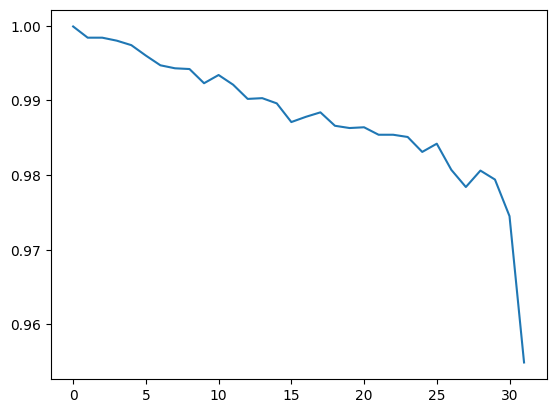

In [13]:
X_test, Y_test = synthetic_data_alignment_clean(num_samples=10**4, num_features=32, seq_length=512, noise=0.0)
Z_test = unet.predict(X_test, batch_size=32)
# ctc decode the predictions, each for 32 features, greedily
Z_test_decoded = K.ctc_decode(Z_test, input_length=np.ones(Z_test.shape[0])*512, greedy=True)[0][0].numpy()
Z_test_decoded = Z_test_decoded[:,0:32]
acc_test = np.mean(Z_test_decoded == Y_test, axis=0)
plt.plot(acc_test)


Epoch 1/101
282/282 [==============================] - 4s 7ms/step - loss: 0.8708 - binary_accuracy: 0.5055 - val_loss: 0.8555 - val_binary_accuracy: 0.5060 - lr: 1.0000e-05
Epoch 2/101
282/282 [==============================] - 2s 8ms/step - loss: 0.7710 - binary_accuracy: 0.5549 - val_loss: 0.8267 - val_binary_accuracy: 0.5354 - lr: 1.0900e-04
Epoch 3/101
282/282 [==============================] - 2s 8ms/step - loss: 0.6580 - binary_accuracy: 0.6307 - val_loss: 0.7032 - val_binary_accuracy: 0.6026 - lr: 2.0800e-04
Epoch 4/101
282/282 [==============================] - 2s 7ms/step - loss: 0.5956 - binary_accuracy: 0.6797 - val_loss: 0.6966 - val_binary_accuracy: 0.6111 - lr: 3.0700e-04
Epoch 5/101
282/282 [==============================] - 2s 6ms/step - loss: 0.5437 - binary_accuracy: 0.7225 - val_loss: 0.7023 - val_binary_accuracy: 0.6144 - lr: 4.0600e-04
Epoch 6/101
282/282 [==============================] - 3s 9ms/step - loss: 0.5024 - binary_accuracy: 0.7520 - val_loss: 0.7288 - v

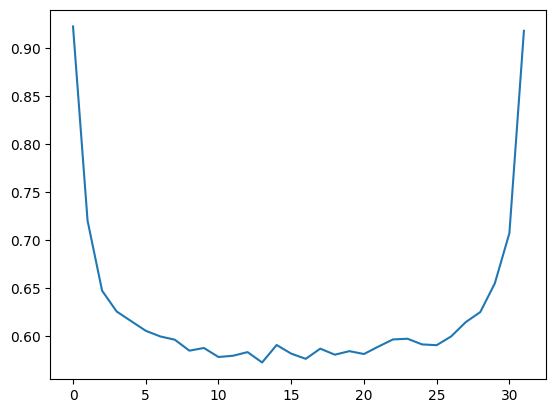

In [15]:
vgg_model_clean = ml.VGG_1D(512, 32, [32,64,128,128],[512,512,512], output_activation='sigmoid',dense_batch_norm=True)
vgg_model_clean.compile(optimizer='adam',loss='binary_crossentropy',metrics='binary_accuracy')
vgg_model_clean.fit(X,Y,epochs=101,batch_size=32,validation_split=0.1,callbacks=[lr_cyclic])
Z_test_vgg = vgg_model_clean.predict(X_test,batch_size=32)
Z_test_vgg_bin = Z_test_vgg > 0.5
acc_test_vgg = np.mean(Z_test_vgg_bin == Y_test, axis=0)
plt.plot(acc_test_vgg)


In [20]:
from experiments import train_unet_ctc
train_unet_ctc(X,Y,epochs=21,batch_size=32)

Epoch 1/21
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5ac35eeef0>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function train_unet_ctc.<locals>.<lambda> at 0x7c5ac35eeef0>: no matching AST found among candidates:
# coding=utf-8
lambda y_true, y_pred: y_pred
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
282/282 [==============================] - 18s 47ms/step - loss: 112.3909 - val_loss: 141.7766 - lr: 1.0000e-05
Epoch 2/21
282/282 [==============================] - 13s 45ms/step - loss: 30.0269 - val_loss: 41.0886 - lr: 1.0900e-04
Epoch 3/21
282/282 [==============================] - 13s 45ms/step - loss: 25.0280 - val_loss: 48.6434 - lr: 2.0800e-04
Epoch 4/21
282/282 [==============================] - 12s 44ms/step

(<keras.src.engine.functional.Functional at 0x7c5ac2bd31c0>,
 <keras.src.callbacks.History at 0x7c5ac21005b0>)

In [21]:
unet2, history = _

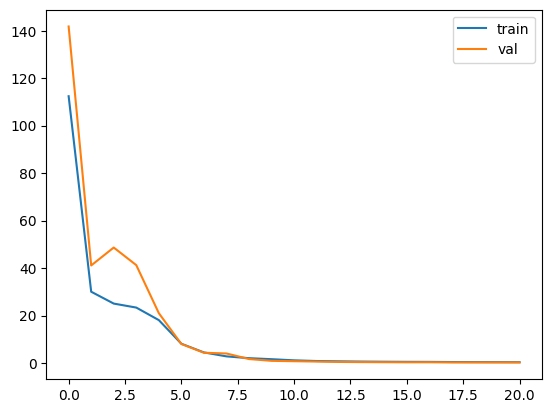

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])
